In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [35]:
np.random.seed(42)
p01 = np.random.geometric(0.1, 10000)
p05 = np.random.geometric(0.5, 10000)
p09 = np.random.geometric(0.9, 10000)

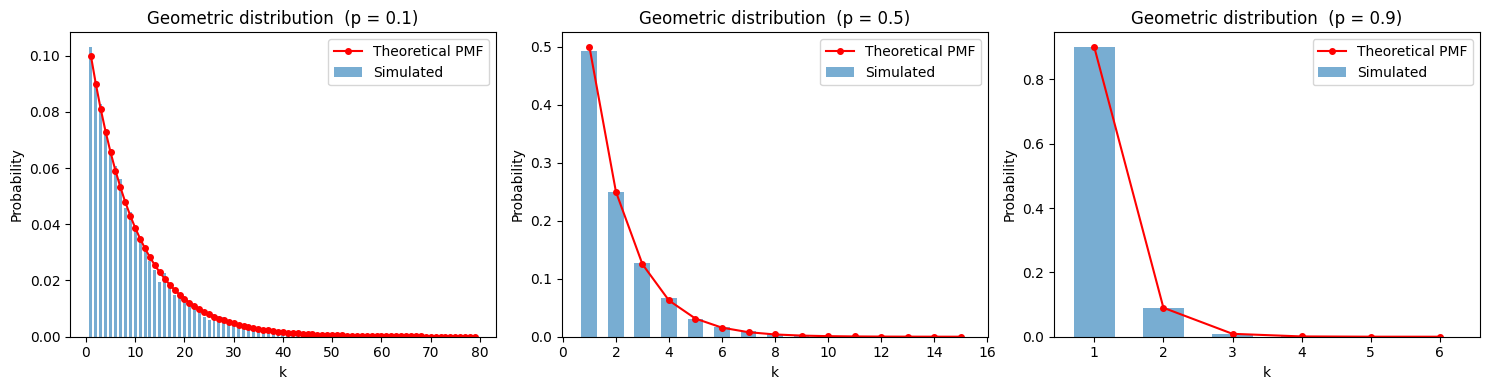

In [18]:
def plot_geometric(samples, p, ax):
    k_max = samples.max() + 1
    k = np.arange(1, k_max + 1)
    pmf = (1 - p) ** (k - 1) * p  # geometric PMF

    # Normalize histogram to probability mass (density=False, divide by n)
    counts, _ = np.histogram(samples, bins=np.arange(1, k_max + 2) - 0.5)
    ax.bar(k, counts / len(samples), width=0.6, alpha=0.6, label="Simulated")
    ax.plot(k, pmf, "ro-", markersize=4, linewidth=1.5, label="Theoretical PMF")
    ax.set_title(f"Geometric distribution  (p = {p})")
    ax.set_xlabel("k")
    ax.set_ylabel("Probability")
    ax.legend()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (samples, p) in zip(axes, [(p01, 0.1), (p05, 0.5), (p09, 0.9)]):
    plot_geometric(samples, p, ax)

plt.tight_layout()
plt.show()


## Inverse Transform Method for Discrete Distributions

Generate $U \sim \mathcal{U}(0,1)$. Return $x_i$ whenever $F(x_{i-1}) < U \leq F(x_i)$, i.e. find the smallest $i$ such that $F(x_i) \geq U$.

In [49]:
sixPointDist = {1: 7/48, 2: 5/48, 3: 1/8, 4: 1/16, 5: 1/4, 6: 5/16}

x_vals = np.array(list(sixPointDist.keys()))
p_vals = np.array(list(sixPointDist.values()))

In [ ]:
def crude_method(x, p, n):
    F = np.cumsum(p)
    U = np.random.uniform(size=n)
    indices = np.searchsorted(F, U, side="left") #search for F(x_i-1) < U < F(x_i)
    return np.array(x)[indices]

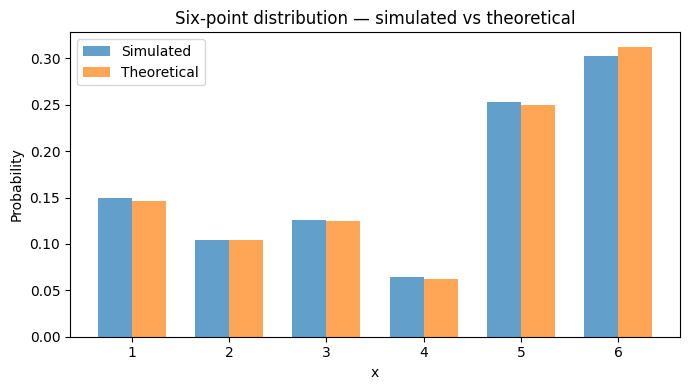

   x  Theoretical  Simulated
   1       0.1458     0.1499
   2       0.1042     0.1048
   3       0.1250     0.1255
   4       0.0625     0.0649
   5       0.2500     0.2527
   6       0.3125     0.3022


In [ ]:
np.random.seed(42)

samples_6 = crude_method(x_vals, p_vals, n=10_000)

emp_pmf_6 = np.array([np.mean(samples_6 == xi) for xi in x_vals])

fig, ax = plt.subplots(figsize=(7, 4))
width = 0.35
ax.bar(x_vals - width/2, emp_pmf_6, width=width, alpha=0.7, label="Simulated")
ax.bar(x_vals + width/2, p_vals,    width=width, alpha=0.7, label="Theoretical")
ax.set_xticks(x_vals)
ax.set_xlabel("x")
ax.set_ylabel("Probability")
ax.set_title("Six-point distribution — simulated vs theoretical")
ax.legend()
plt.tight_layout()
plt.show()

print(f"{'x':>4} {'Theoretical':>12} {'Simulated':>10}")
for xi, pt, ps in zip(x_vals, p_vals, emp_pmf_6):
    print(f"{xi:>4} {pt:>12.4f} {ps:>10.4f}")


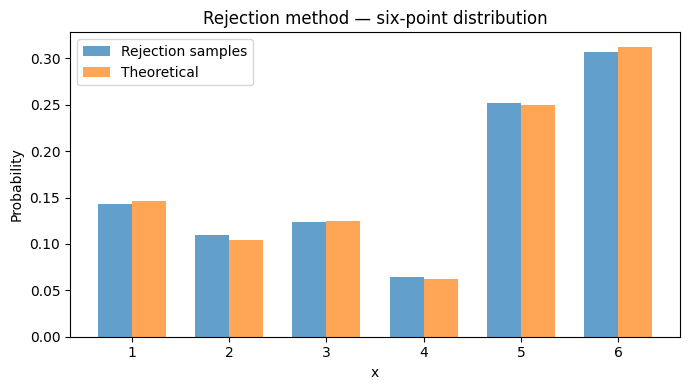

Expected trials per sample: 1.875


In [ ]:
# Rejection Method
def simple_rejection_method(x, p, n):
    k = len(x)
    c = np.max(p)   # optimal: minimises expected  number of trials
    samples = []
    while len(samples) < n:
        I  = int(np.floor(k * np.random.uniform()))  # uniform index in {0,...,k-1}
        U2 = np.random.uniform()
        if U2 <= p[I] / c:
            samples.append(x[I])
    return np.array(samples)


np.random.seed(42)
samples_rej = simple_rejection_method(x_vals, p_vals, n=10_000)
emp_pmf_rej = np.array([np.mean(samples_rej == xi) for xi in x_vals])

fig, ax = plt.subplots(figsize=(7, 4))
width = 0.35
ax.bar(x_vals - width/2, emp_pmf_rej, width=width, alpha=0.7, label="Rejection samples")
ax.bar(x_vals + width/2, p_vals,      width=width, alpha=0.7, label="Theoretical")
ax.set_xticks(x_vals)
ax.set_xlabel("x")
ax.set_ylabel("Probability")
ax.set_title("Rejection method — six-point distribution")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Expected trials per sample: {len(x_vals) * np.max(p_vals):.3f}")


In [55]:
# Alias Method

def alias_setup(p):
    """Build Prob and Alias tables from probability array p (sums to 1)."""
    n = len(p)
    prob  = np.zeros(n)
    alias = np.zeros(n, dtype=int)

    scaled = np.array(p, dtype=float) * n   # scale so each bucket has weight 1
    small  = [i for i, q in enumerate(scaled) if q < 1]
    large  = [i for i, q in enumerate(scaled) if q >= 1]

    while small and large:
        l = small.pop()
        g = large.pop()
        prob[l]   = scaled[l]
        alias[l]  = g
        scaled[g] = scaled[g] + scaled[l] - 1   # leftover from g fills l
        if scaled[g] < 1:
            small.append(g)
        else:
            large.append(g)

    for i in large + small:
        prob[i] = 1.0

    return prob, alias


def alias_sample(x, prob, alias, n):
    """Draw n samples using pre-built Prob/Alias tables."""
    k = len(x)
    I     = np.random.randint(0, k, size=n)       # uniform column index
    U     = np.random.uniform(size=n)
    picks = np.where(U < prob[I], I, alias[I])    # one comparison per sample
    return np.array(x)[picks]


Alias tables:
   i    x_i    Prob[i]   Alias[i]
   0      1     0.8750          5
   1      2     0.6250          6
   2      3     0.7500          6
   3      4     0.3750          6
   4      5     1.0000          1
   5      6     0.6250          5


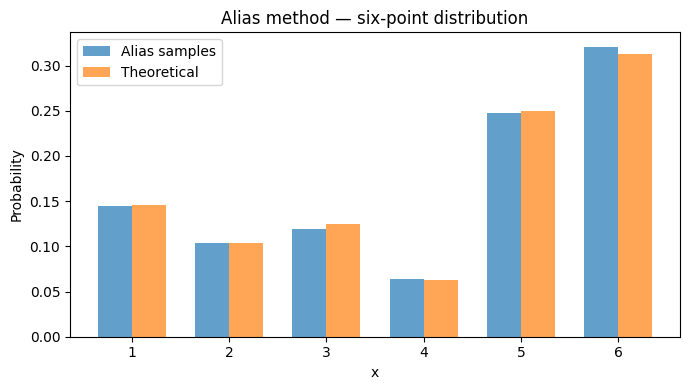

In [56]:
np.random.seed(42)

prob_table, alias_table = alias_setup(p_vals)

print("Alias tables:")
print(f"{'i':>4} {'x_i':>6} {'Prob[i]':>10} {'Alias[i]':>10}")
for i, (xi, pr, al) in enumerate(zip(x_vals, prob_table, alias_table)):
    print(f"{i:>4} {xi:>6} {pr:>10.4f} {x_vals[al]:>10}")

samples_alias = alias_sample(x_vals, prob_table, alias_table, n=10_000)
emp_pmf_alias = np.array([np.mean(samples_alias == xi) for xi in x_vals])

fig, ax = plt.subplots(figsize=(7, 4))
width = 0.35
ax.bar(x_vals - width/2, emp_pmf_alias, width=width, alpha=0.7, label="Alias samples")
ax.bar(x_vals + width/2, p_vals,        width=width, alpha=0.7, label="Theoretical")
ax.set_xticks(x_vals)
ax.set_xlabel("x")
ax.set_ylabel("Probability")
ax.set_title("Alias method — six-point distribution")
ax.legend()
plt.tight_layout()
plt.show()

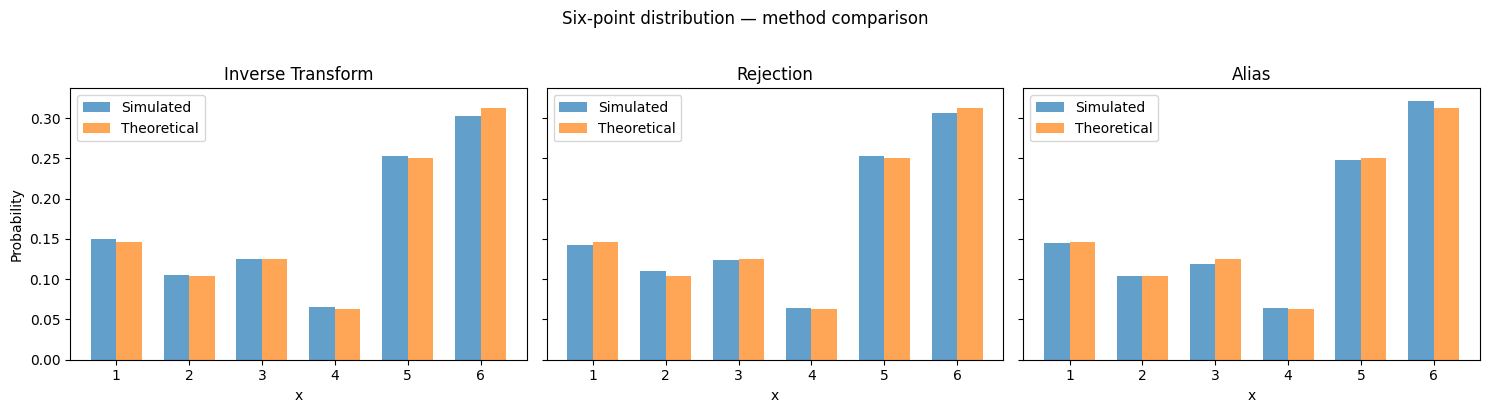

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

methods = [
    ("Inverse Transform", emp_pmf_6),
    ("Rejection",         emp_pmf_rej),
    ("Alias",             emp_pmf_alias),
]

width = 0.35
for ax, (title, emp) in zip(axes, methods):
    ax.bar(x_vals - width/2, emp,    width=width, alpha=0.7, label="Simulated")
    ax.bar(x_vals + width/2, p_vals, width=width, alpha=0.7, label="Theoretical")
    ax.set_title(title)
    ax.set_xticks(x_vals)
    ax.set_xlabel("x")
    ax.legend()

axes[0].set_ylabel("Probability")
plt.suptitle("Six-point distribution — method comparison", y=1.02)
plt.tight_layout()
plt.show()
